# Research into apartment sale listings

You have data from the Yandex Real Estate service at your disposal — an archive of apartment sale listings for St. Petersburg and neighboring localities over several years. You need to learn how to determine the market value of real estate objects. Your task is to establish the parameters. This will make it possible to build an automated system: it will detect anomalies and fraudulent activity.

Two types of data are available for each apartment for sale. The first are entered by the user, the second are obtained automatically based on map data. For example, distance to the city center, the airport, the nearest park, and the nearest body of water. 

### Open the data file and study the general information. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

In [3]:
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

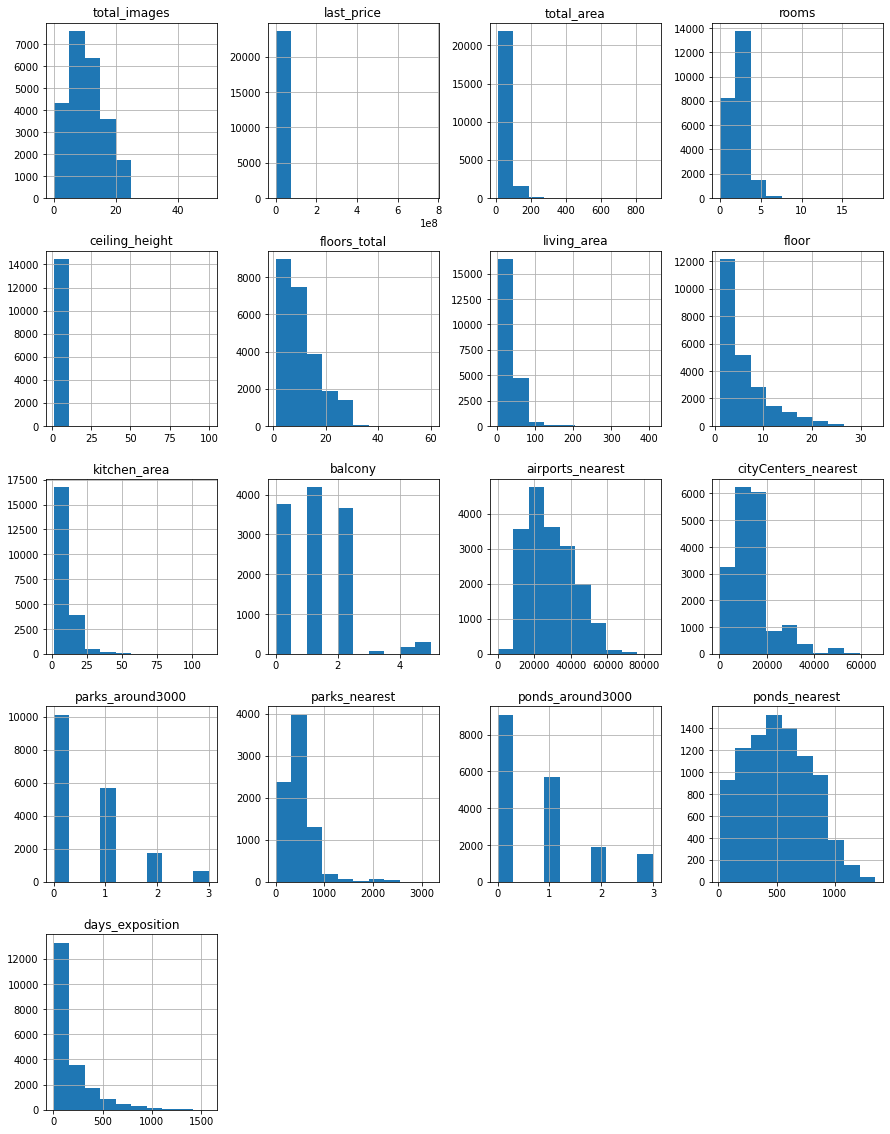

In [5]:
data.hist(figsize=(15, 20));

### Data preprocessing

#### Let's determine the number of missing values in the table

In [6]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

In [7]:
# check
# missing value bars

def pass_value_barh(df):
    try:
        (
            (df.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), rot = -5, legend = False, fontsize = 16)
            .set_title('Example' + "\n", fontsize = 22, color = 'SteelBlue')
        );
    except:
        print('no missing values left :) or an error occurred in the first part of the function ')

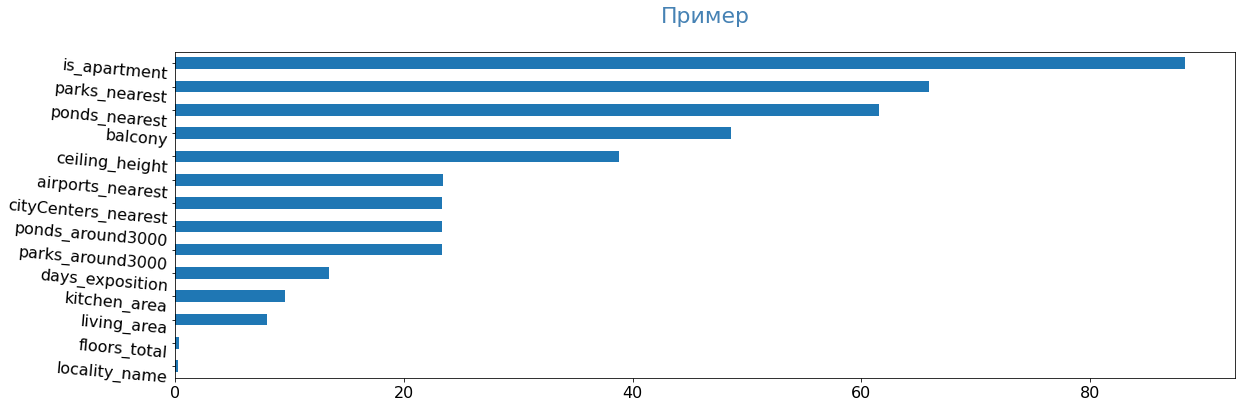

In [8]:
pass_value_barh(data)

#### Handle missing values in the ['ceiling_height'] column

In [9]:
data['ceiling_height'].unique()

array([  2.7 ,    nan,   3.03,   2.5 ,   2.67,   2.56,   3.05,   2.75,
         2.6 ,   2.9 ,   2.8 ,   2.55,   3.  ,   2.65,   3.2 ,   2.61,
         3.25,   3.45,   2.77,   2.85,   2.64,   2.57,   4.15,   3.5 ,
         3.3 ,   2.71,   4.  ,   2.47,   2.73,   2.84,   3.1 ,   2.34,
         3.4 ,   3.06,   2.72,   2.54,   2.51,   2.78,   2.76,  25.  ,
         2.58,   3.7 ,   2.52,   5.2 ,   2.87,   2.66,   2.59,   2.  ,
         2.45,   3.6 ,   2.92,   3.11,   3.13,   3.8 ,   3.15,   3.55,
         3.16,   3.62,   3.12,   2.53,   2.74,   2.96,   2.46,   5.3 ,
         5.  ,   2.79,   2.95,   4.06,   2.94,   3.82,   3.54,   3.53,
         2.83,   4.7 ,   2.4 ,   3.38,   3.01,   5.6 ,   3.65,   3.9 ,
         3.18,   3.35,   2.3 ,   3.57,   2.48,   2.62,   2.82,   3.98,
         2.63,   3.83,   3.52,   3.95,   3.75,   2.88,   3.67,   3.87,
         3.66,   3.85,   3.86,   4.19,   3.24,   4.8 ,   4.5 ,   4.2 ,
         3.36,  32.  ,   3.08,   3.68,   3.07,   3.37,   3.09,   8.  ,
      

<AxesSubplot:>

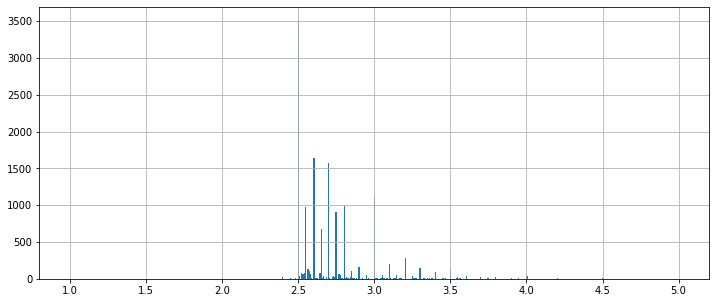

In [10]:
#let's build a histogram for ceiling height

data['ceiling_height'].hist(bins= 500, range =(1,5), figsize =(12,5))

In [11]:
data['ceiling_height'].value_counts()

2.50     3515
2.60     1646
2.70     1574
3.00     1112
2.80      993
         ... 
4.25        1
3.39        1
3.93        1
10.30       1
4.65        1
Name: ceiling_height, Length: 183, dtype: int64

In [12]:
#determine the average ceiling height in the center of St. Petersburg, since the city is known for its high ceilings

ceiling_spb_center_mean = data[(data['locality_name'] == 'Санкт-Петербург')
                          & (data['cityCenters_nearest'] <= 5000)]['ceiling_height'].mean()
display(ceiling_spb_center_mean)

3.202702312138728

In [13]:
#let's replace missing values with the mean value for the center of St. Petersburg

data.loc[(data['locality_name'] == 'Санкт-Петербург') & (data['cityCenters_nearest'] <= 5000) & (data['ceiling_height'].isna()), 'ceiling_height'] = ceiling_spb_center_mean

In [14]:
#let's check the remaining number of missing values

data['ceiling_height'].isna().sum()

8513

In [15]:
#determine the average ceiling height for all other locations

other_ceiling_mean =  data.loc[data['locality_name'] != 'Санкт-Петербург', 'ceiling_height'].mean()
display(other_ceiling_mean)

2.697531818181818

In [16]:
#let's replace all remaining missing values with the resulting mean value

data['ceiling_height'] = data['ceiling_height'].fillna(other_ceiling_mean)

In [17]:
#let's check the column for missing values

data['ceiling_height'].isna().sum()

0

In [18]:
#let's remove anomalies

data = data.loc[(data['ceiling_height'] >= 2.20) & (data['ceiling_height'] <= 4.00)]

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23610 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23610 non-null  int64  
 1   last_price            23610 non-null  float64
 2   total_area            23610 non-null  float64
 3   first_day_exposition  23610 non-null  object 
 4   rooms                 23610 non-null  int64  
 5   ceiling_height        23610 non-null  float64
 6   floors_total          23524 non-null  float64
 7   living_area           21715 non-null  float64
 8   floor                 23610 non-null  int64  
 9   is_apartment          2753 non-null   object 
 10  studio                23610 non-null  bool   
 11  open_plan             23610 non-null  bool   
 12  kitchen_area          21347 non-null  float64
 13  balcony               12134 non-null  float64
 14  locality_name         23561 non-null  object 
 15  airports_nearest   

In [20]:
data['ceiling_height'].describe()

count    23610.000000
mean         2.726790
std          0.217571
min          2.200000
25%          2.600000
50%          2.697532
75%          2.700000
max          4.000000
Name: ceiling_height, dtype: float64

**Missing values and anomalous values were found in the ['ceiling_height'] column. Ceiling height on average ranges from 2.5 m to 4 m, but outliers were also found, such as 1.2 m and also 24, 27, 100.
We took a sample for the center of St. Petersburg and for all other locations, determined two mean values, and replaced the missing values for each of the two groups accordingly. We also removed the outliers and anomalies**

#### Handling missing values in the ['balcony'] column

In [21]:
#let's replace all missing values with 0
data['balcony']=data['balcony'].fillna(0)

In [22]:
data['balcony'].isna().sum()

0

In [23]:
# change the data type to integer

data['balcony'] = data['balcony'].astype('int')

In [24]:
data['balcony'].unique()

array([0, 2, 1, 5, 4, 3])

In [25]:
display(data['balcony'].value_counts())


0    15224
1     4177
2     3645
5      301
4      182
3       81
Name: balcony, dtype: int64

**Missing values in the ['balcony'] column mean the absence of a balcony, so we replaced them with 0. We also converted the data type from float to integer, since the presence or absence of a balcony can only be described by a whole number.**

#### Handling missing values in the ['floors_total'] column

In [26]:
# let's drop the empty rows, since they can't be replaced, and their small number lets us do this
# without a significant impact on the data's objectivity

data = data.dropna(subset=['floors_total'])
data['floors_total'].isna().sum()

0

In [27]:
#change the data type to integer

data['floors_total'] = data['floors_total'].astype('int')

In [28]:
#determine the quantiles for the number-of-floors column

Q1 = data['floors_total'].quantile(0.25)
Q3 = data['floors_total'].quantile(0.75)
IQR = Q3 - Q1

#determine the lower and upper bounds

upper_bound = Q3 + 1.5*IQR
lower_bound = Q1 - 1.5*IQR

#remove data outside the lower and upper bounds

data = data[(data['floors_total'] >= lower_bound) & (data['floors_total'] <= upper_bound)]

data['floors_total'].describe()


count    23494.000000
mean        10.652294
std          6.531603
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         29.000000
Name: floors_total, dtype: float64

In [29]:
data['floors_total'].value_counts()

5     5758
9     3757
16    1373
12    1360
4     1192
10    1173
25    1074
6      905
17     831
3      658
7      586
14     551
18     504
24     468
8      389
2      379
15     364
23     352
19     339
22     286
20     271
13     229
11     203
27     164
21     158
26     123
1       25
28      21
29       1
Name: floors_total, dtype: int64

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23494 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23494 non-null  int64  
 1   last_price            23494 non-null  float64
 2   total_area            23494 non-null  float64
 3   first_day_exposition  23494 non-null  object 
 4   rooms                 23494 non-null  int64  
 5   ceiling_height        23494 non-null  float64
 6   floors_total          23494 non-null  int64  
 7   living_area           21633 non-null  float64
 8   floor                 23494 non-null  int64  
 9   is_apartment          2749 non-null   object 
 10  studio                23494 non-null  bool   
 11  open_plan             23494 non-null  bool   
 12  kitchen_area          21281 non-null  float64
 13  balcony               23494 non-null  int64  
 14  locality_name         23446 non-null  object 
 15  airports_nearest   

**Rows with missing values for the number of floors were removed, since they couldn't be replaced with a corresponding value. 86 missing values won't significantly affect the overall conclusions. The data type was also changed from float to integer, since the number of floors can only be counted in whole numbers. Using quantiles we identified and removed anomalies and outstanding values.**

#### Handling missing values in the ['kitchen_area'] column

In [31]:
# let's determine how kitchen area and studio type relate to each other

studio_data = data[data['studio']== True]
studio_data = studio_data[['living_area', 'kitchen_area', 'total_area', 'is_apartment']]
display(studio_data)

#the table shows that the missing values are related

,living_area,kitchen_area,total_area,is_apartment
144,15.50,NaN,27.00,NaN
440,24.75,NaN,27.11,NaN
608,NaN,NaN,25.00,NaN
697,17.50,NaN,24.10,NaN
716,12.00,NaN,17.00,NaN
...,...,...,...,...
22867,18.20,NaN,30.00,NaN
22877,18.00,NaN,28.00,NaN
23210,18.00,NaN,26.00,NaN
23554,NaN,NaN,26.00,NaN


In [32]:
#let's replace the empty rows in the 'kitchen_area' column that correspond to studios with zero

studio_data['kitchen_area'].fillna(0, inplace=True)
data.update(studio_data)

In [33]:
# determine the number of empty rows after the replacement

data['kitchen_area'].isna().sum()

2069

In [34]:
# determine the average kitchen area and fill the empty values with the mean value

kitchen_mean = data['kitchen_area'].mean()
data['kitchen_area'] = data['kitchen_area'].fillna(kitchen_mean)
data['kitchen_area'].isna().sum()

0

<AxesSubplot:>

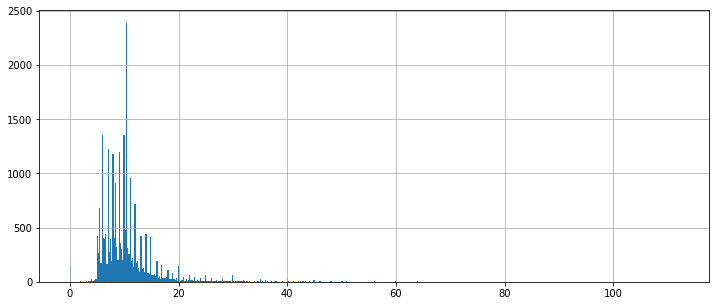

In [35]:
data['kitchen_area'].hist(bins=500, figsize=(12,5))

In [36]:
#remove anomalous values and tails in line with the histogram

data = data.loc[(data['kitchen_area'] >= 0) & (data['kitchen_area'] <= 31.0)]

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23196 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23196 non-null  int64  
 1   last_price            23196 non-null  float64
 2   total_area            23196 non-null  float64
 3   first_day_exposition  23196 non-null  object 
 4   rooms                 23196 non-null  int64  
 5   ceiling_height        23196 non-null  float64
 6   floors_total          23196 non-null  int64  
 7   living_area           21354 non-null  float64
 8   floor                 23196 non-null  int64  
 9   is_apartment          2714 non-null   object 
 10  studio                23196 non-null  bool   
 11  open_plan             23196 non-null  bool   
 12  kitchen_area          23196 non-null  float64
 13  balcony               23196 non-null  int64  
 14  locality_name         23149 non-null  object 
 15  airports_nearest   

In [38]:
data['kitchen_area'].describe()

count    23196.000000
mean        10.058259
std          4.094179
min          0.000000
25%          7.200000
50%          9.795000
75%         11.200000
max         31.000000
Name: kitchen_area, dtype: float64

#### check nan

**We replaced the missing values and removed anomalies in the 'kitchen_area' column. Empty rows belonging to the studio characteristic were replaced with a value of zero, since it's logical that a studio doesn't have a separate kitchen. The remaining empty rows were replaced with the mean kitchen area value. We also identified and removed anomalous values.**

#### Handling missing values and anomalous values in the ['living_area'] column

In [39]:
#let's create a column with non-residential area

data['non_liv'] = data['total_area'] - data['living_area'] - data['kitchen_area']

#determine the mean non-residential area value

non_liv_mean = data['non_liv'].mean()

#determine the mean total area value

total_area_mean = data['total_area'].mean()

#determine the ratio of non-residential area to total area

ratio = non_liv_mean/total_area_mean

display(ratio)

0.25161077323493214

In [40]:
#let's fill in missing values in the living-area column by subtracting kitchen area and non-residential area from total area

data['living_area'] = data['living_area'].fillna(data['total_area'] - data['kitchen_area'] - (data['total_area'] * ratio))

In [41]:
#let's print the number of missing values after the replacement

data['living_area'].isna().sum()

0

<AxesSubplot:>

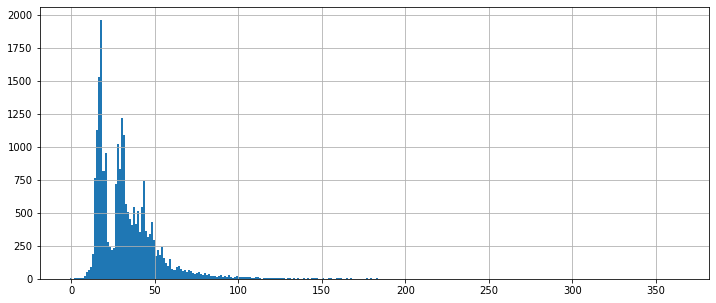

In [42]:
data['living_area'].hist(bins =300, figsize=(12,5))

In [43]:
data['living_area'].describe()

count    23196.000000
mean        33.936181
std         20.872561
min         -0.743115
25%         18.600000
50%         30.000000
75%         42.000000
max        363.722439
Name: living_area, dtype: float64

In [44]:
#remove negative values

data['living_area'] = data['living_area'].abs()

In [45]:
data['living_area'].describe()

count    23196.000000
mean        33.936361
std         20.872269
min          0.593437
25%         18.600000
50%         30.000000
75%         42.000000
max        363.722439
Name: living_area, dtype: float64

In [46]:
#remove anomalies and outliers

data = data.loc[(data['living_area'] >= 10) & (data['living_area'] <= 100)]

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22784 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          22784 non-null  int64  
 1   last_price            22784 non-null  float64
 2   total_area            22784 non-null  float64
 3   first_day_exposition  22784 non-null  object 
 4   rooms                 22784 non-null  int64  
 5   ceiling_height        22784 non-null  float64
 6   floors_total          22784 non-null  int64  
 7   living_area           22784 non-null  float64
 8   floor                 22784 non-null  int64  
 9   is_apartment          2668 non-null   object 
 10  studio                22784 non-null  bool   
 11  open_plan             22784 non-null  bool   
 12  kitchen_area          22784 non-null  float64
 13  balcony               22784 non-null  int64  
 14  locality_name         22737 non-null  object 
 15  airports_nearest   

In [48]:
data['living_area'].describe()

count    22784.000000
mean        32.439628
std         15.670391
min         10.000000
25%         18.600000
50%         30.000000
75%         41.600000
max        100.000000
Name: living_area, dtype: float64

**We determined the ratio coefficient of non-residential area to total area and used it to fill in the missing values in the living area column.
We also identified and removed anomalies.**

#### Let's check for anomalies in the data['rooms'] column

In [49]:
#determine whether there are anomalies

data['rooms'].value_counts()

1    7918
2    7797
3    5619
4    1042
5     193
0     185
6      23
7       7
Name: rooms, dtype: int64

In [50]:
data['rooms'].describe()

count    22784.000000
mean         2.005311
std          0.953751
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

No anomalies found

#### Let's remove anomalies from the ['total_area'] column

<AxesSubplot:>

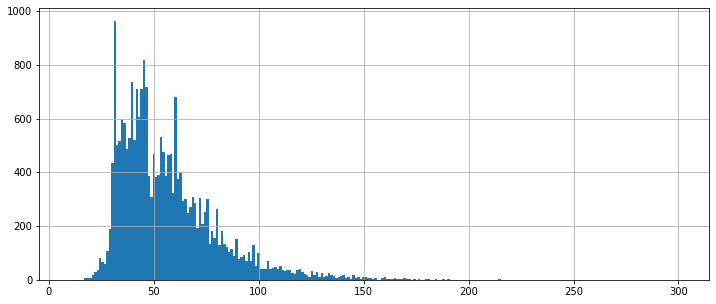

In [51]:
#let's build a histogram to identify anomalies

data['total_area'].hist(bins = 250, figsize = (12,5), range =(10,300))

The histogram shows that there are outlying values below 20 and above 150 sq m

In [52]:
#let's remove rows with outlying values

data = data[(data['total_area'] >= 20) & (data['total_area'] <= 150)]

In [53]:
data['total_area'].describe()

count    22642.000000
mean        56.077805
std         22.134221
min         20.000000
25%         40.000000
50%         51.000000
75%         67.000000
max        150.000000
Name: total_area, dtype: float64

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22642 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          22642 non-null  int64  
 1   last_price            22642 non-null  float64
 2   total_area            22642 non-null  float64
 3   first_day_exposition  22642 non-null  object 
 4   rooms                 22642 non-null  int64  
 5   ceiling_height        22642 non-null  float64
 6   floors_total          22642 non-null  int64  
 7   living_area           22642 non-null  float64
 8   floor                 22642 non-null  int64  
 9   is_apartment          2652 non-null   object 
 10  studio                22642 non-null  bool   
 11  open_plan             22642 non-null  bool   
 12  kitchen_area          22642 non-null  float64
 13  balcony               22642 non-null  int64  
 14  locality_name         22596 non-null  object 
 15  airports_nearest   

We removed the outlying values

#### Let's remove anomalies and outlying values from the 'last_price' column

<AxesSubplot:>

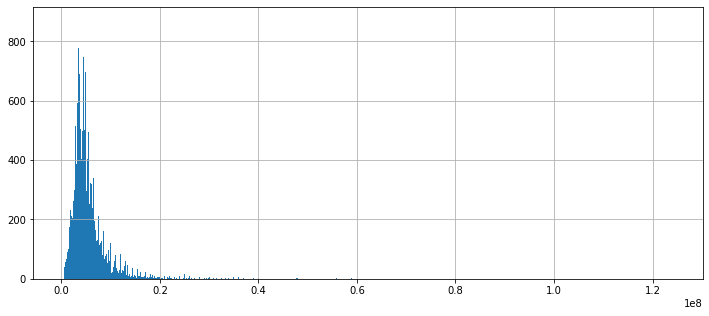

In [55]:
data['last_price'].hist(bins=1000, figsize=(12,5))

In [56]:
#determine the quantiles for the price column

Q1 = data['last_price'].quantile(0.25)
Q3 = data['last_price'].quantile(0.75)
IQR = Q3 - Q1

#determine the lower and upper bounds

upper_bound = Q3 + 4*IQR
lower_bound = Q1 - 4*IQR

#remove data outside the lower and upper bounds

data = data[(data['last_price'] >= lower_bound) & (data['last_price'] <= upper_bound)]

data['last_price'].describe()

count    2.232600e+04
mean     5.252767e+06
std      2.923310e+06
min      4.300000e+05
25%      3.390000e+06
50%      4.500000e+06
75%      6.320000e+06
max      1.890000e+07
Name: last_price, dtype: float64

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22326 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          22326 non-null  int64  
 1   last_price            22326 non-null  float64
 2   total_area            22326 non-null  float64
 3   first_day_exposition  22326 non-null  object 
 4   rooms                 22326 non-null  int64  
 5   ceiling_height        22326 non-null  float64
 6   floors_total          22326 non-null  int64  
 7   living_area           22326 non-null  float64
 8   floor                 22326 non-null  int64  
 9   is_apartment          2605 non-null   object 
 10  studio                22326 non-null  bool   
 11  open_plan             22326 non-null  bool   
 12  kitchen_area          22326 non-null  float64
 13  balcony               22326 non-null  int64  
 14  locality_name         22281 non-null  object 
 15  airports_nearest   

We removed anomalous values using quantiles.

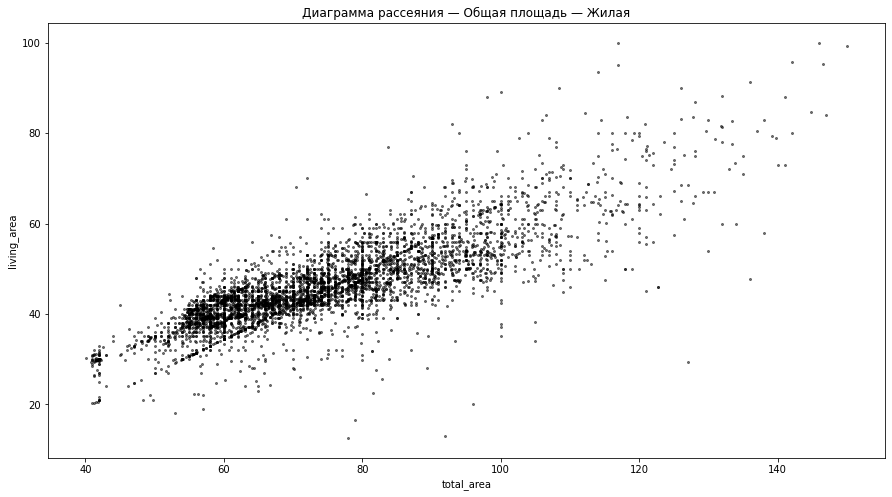

In [58]:
# check
data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(kind='scatter',
        y='living_area' , x='total_area', alpha=0.5, subplots=True, figsize=(15,8), c = 'black', s = 4)
plt.title('Scatter plot — Total area — Living area');

#### Handling missing values in the ['locality_name'] column and removing duplicates

In [59]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [60]:
#remove empty rows and check for missing values

data = data.dropna(subset=['locality_name'])
data['locality_name'].isna().sum()

0

In [61]:
#there are implicit duplicates in the data — let's normalize the string values to make them easier to work with

data['locality_name'] = data['locality_name'].str.replace('поселок', 'посёлок')

In [62]:
#let's create a function that strips settlement-type words and leaves only the names

replace_list= [
    'посёлок', 'городского типа', 'деревня', 'городской', 'коттеджный', 'садовое товарищество',
    'станции', 'село', 'садоводческое некоммерческое товарищество']

def loc_replace(row):
    try:
        for i in replace_list:
            if i in row:
                row = row.replace(i, '')
        return row
    except:
        return row
data['locality_name'] = data['locality_name'].apply(loc_replace)
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,non_liv
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.700000,16,51.000000,8,NaN,...,0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,32.00
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,2.697532,11,18.600000,1,NaN,...,2,Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,10.80
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,2.697532,5,34.300000,4,NaN,...,0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,13.40
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,2.697532,12,14.400000,5,NaN,...,0,Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0,6.90
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,2.697532,26,10.600000,6,NaN,...,1,Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,12.30
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,2.697532,24,34.684669,22,NaN,...,2,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,2.697532,27,15.430000,26,NaN,...,0,Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0,8.92
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.500000,9,43.600000,7,NaN,...,2,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0,10.90
10,5,5050000.0,39.60,2017-11-16T00:00:00,1,2.670000,12,20.300000,3,NaN,...,0,Санкт-Петербург,38357.0,13878.0,1.0,310.0,2.0,553.0,137.0,10.80
11,9,3300000.0,44.00,2018-08-27T00:00:00,2,2.697532,5,31.000000,4,False,...,1,Ломоносов,48252.0,51677.0,0.0,NaN,0.0,NaN,7.0,7.00


We got rid of implicit duplicates in the location names, keeping only the names for easier further work with this data. We also removed empty rows.

Note: the settlement-type strings above (e.g. 'посёлок', 'деревня') are kept in Russian on purpose — they match the actual locality names in the source dataset.

In [63]:
# check
data.locality_name.nunique()

316

In [64]:
# check
data.locality_name.unique()

array(['Санкт-Петербург', ' Шушары', '  Янино-1', ' Парголово', ' Мурино',
       'Ломоносов', 'Сертолово', 'Петергоф', 'Пушкин', ' Кудрово',
       'Коммунар', 'Колпино', '  Красный Бор', 'Гатчина', ' Фёдоровское',
       'Выборг', 'Кронштадт', 'Кировск', ' Новое Девяткино',
       ' Металлострой', '  Лебяжье', '  Сиверский', ' Молодцово',
       '  Кузьмоловский', ' Новая Ропша', 'Павловск', ' Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       ' Куттузи', ' Аннино', '  Ефимовский', ' Плодовое', ' Заклинье',
       ' Торковичи', ' Первомайское', 'Красное Село', ' Понтонный',
       'Сясьстрой', ' Старая', ' Лесколово', ' Новый Свет', 'Сланцы',
       ' Путилово', 'Ивангород', 'Мурино', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый Бор', ' Оржицы', ' Кальтино', 'Кудрово',
       ' Романовка', ' Бугры', '  Рощино', 'Кириши', 'Луга', 'Волосово',
       'Отрадное', ' Павлово', ' Оредеж', ' Копорье', ' Молодёжное',
       'Тихвин', ' П

#### Handling missing values in the ['is_apartment'] column

In [65]:
#change the data type to boolean

data['is_apartment'] = data['is_apartment'].astype('bool')

In [66]:
#let's check whether there's a relationship between studio and apartment type

apart_data = data[data['is_apartment']== True]
apart_data = apart_data[['studio']]
display(apart_data)

,studio
0,False
1,False
2,False
5,False
6,False
...,...
23694,False
23695,False
23696,False
23697,False


In [67]:
#let's replace missing values in ['is_apartment'] with False where ['studio'] == True
#check for missing values after the replacement

data.loc[data['studio'] ==True, 'is_apartment'] = data.loc[data['studio'] ==True, 'is_apartment'].fillna(False)
data['is_apartment'].isna().sum()

0

In [68]:
data['is_apartment'].unique()

array([ True, False])

Missing values were found in the rows marked as a studio. Such missing values were replaced with the corresponding boolean value. 

#### Let's remove anomalies in the days_exposition column

In [69]:
data['days_exposition'].describe()

count    19436.000000
mean       176.480603
std        215.105377
min          1.000000
25%         44.000000
50%         93.000000
75%        224.000000
max       1580.000000
Name: days_exposition, dtype: float64

<AxesSubplot:>

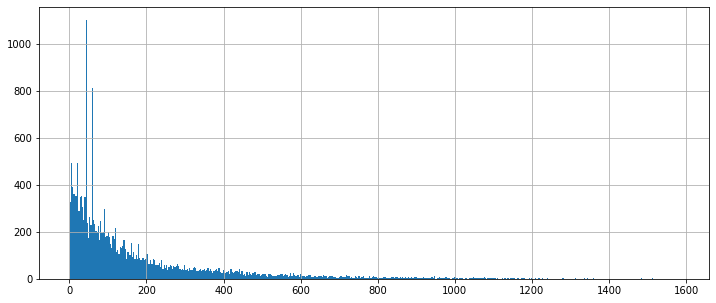

In [70]:
data['days_exposition'].hist(bins=500, figsize=(12,5))

In [71]:
#remove anomalies and outlying values

data = data.loc[(data['days_exposition'] >= 3) & (data['days_exposition'] < 800) |
                (data.isna().any(axis=1)), :]

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22165 entries, 0 to 23698
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          22165 non-null  int64  
 1   last_price            22165 non-null  float64
 2   total_area            22165 non-null  float64
 3   first_day_exposition  22165 non-null  object 
 4   rooms                 22165 non-null  int64  
 5   ceiling_height        22165 non-null  float64
 6   floors_total          22165 non-null  int64  
 7   living_area           22165 non-null  float64
 8   floor                 22165 non-null  int64  
 9   is_apartment          22165 non-null  bool   
 10  studio                22165 non-null  bool   
 11  open_plan             22165 non-null  bool   
 12  kitchen_area          22165 non-null  float64
 13  balcony               22165 non-null  int64  
 14  locality_name         22165 non-null  object 
 15  airports_nearest   

**Using the histogram and the describe method, we determined that there are anomalous values in the form of suspiciously short listing durations of 1-2 days, and we also removed abnormally long listings lasting more than 800 days.**

#### check gap

In [73]:
# check

# Metrics on the number of listings in the dataset, and the minimum and maximum values
# for the selected apartment-sale parameters
# raw data

(
    data[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  'kitchen_area',
          'floor', 'floors_total']]
    .apply (['count', 'min', 'max'])
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
count,"22,165.00","22,165.00","22,165.00","19,320.00","22,165.00","22,165.00","22,165.00","22,165.00","22,165.00"
min,0.00,20.00,2.20,2.00,"430,000.00",10.00,0.00,1.00,1.00
max,7.00,150.00,4.00,"1,580.00","18,900,000.00",100.00,31.00,27.00,29.00


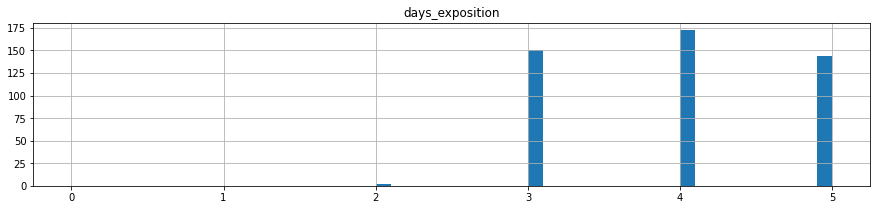

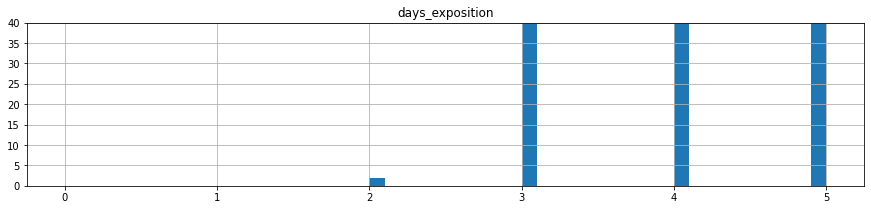

In [74]:
# check
data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5));

data.hist(column = 'days_exposition', bins = 50, figsize = (15,3), range = (0,5))
plt.ylim(0, 40);

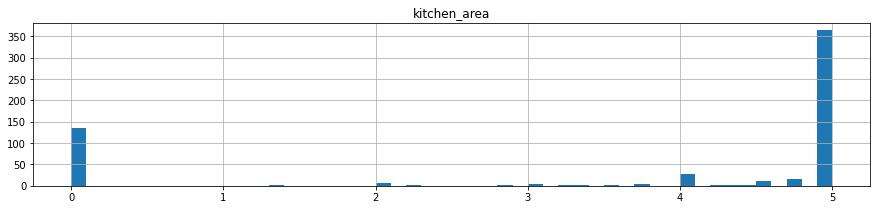

In [75]:
# check
data.hist(column = 'kitchen_area', bins = 50, figsize = (15,3), range = (0,5));

In [76]:
# check

try:
    df_check = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t')
# if reading the file from the local folder didn't work, load the data from the network
except:
    df_check = pd.read_csv('real_estate_data.csv', sep='\t')

In [77]:
# check
df_check.rooms.value_counts().to_frame()

,rooms
1,8047
2,7940
3,5814
4,1180
5,326
0,197
6,105
7,59
8,12
9,8


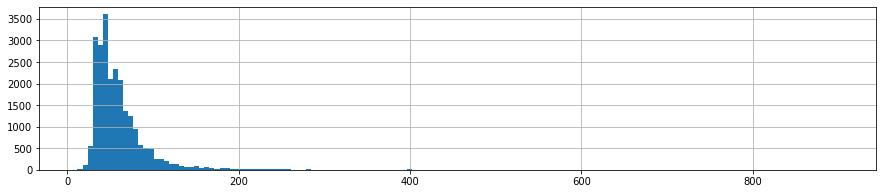

In [78]:
# check
df_check.total_area.hist(bins = 150, figsize = (15,3));

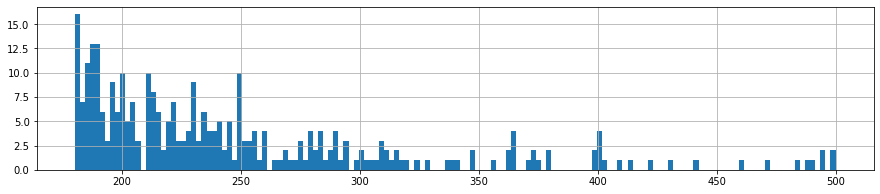

In [79]:
# check
df_check.total_area.hist(bins = 150, figsize = (15,3), range = (180,500));

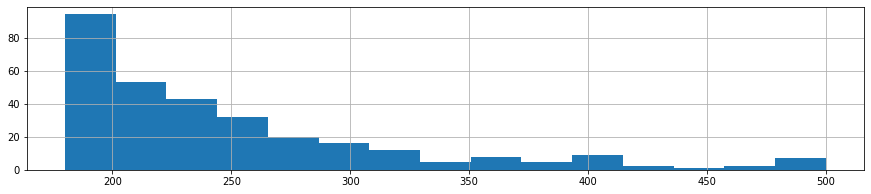

In [80]:
# check
df_check.total_area.hist(bins = 15, figsize = (15,3), range = (180,500));

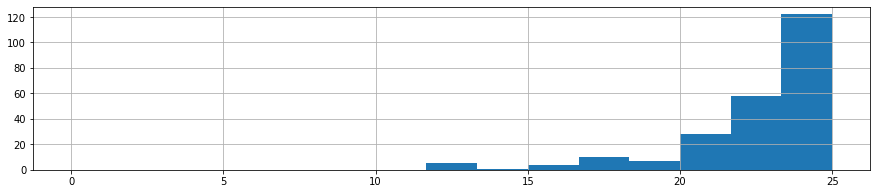

In [81]:
# check
df_check.total_area.hist(bins = 15, figsize = (15,3), range = (0,25));

In [82]:
# check

# Parameter values for real estate objects at different quantiles

(
    data[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',
        'kitchen_area', 'floor',   'floors_total']]
    .quantile([0.0012, 0.01, .5, .99, .9988]) # choose a spread of 0.9976 quantiles
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
0.0012,0.00,21.90,2.40,3.00,"562,984.00",10.05,0.00,1.00,2.00
0.01,1.00,26.00,2.50,4.00,"1,000,000.00",12.73,4.86,1.00,2.00
0.5,2.00,50.40,2.70,92.00,"4,500,000.00",29.80,9.40,4.00,9.00
0.99,4.00,122.00,3.50,984.81,"15,500,000.00",78.00,24.00,23.00,26.00
0.9988,5.00,143.58,3.96,"1,341.81","18,372,146.15",95.00,30.00,26.00,27.00


### Calculate and add new columns to the table

In [83]:
# add a new column to the table with the price per 1 sq m

data['price_per_sqm'] = data['last_price']/data['total_area']
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.700000,16,51.0,8,True,...,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,32.0,120370.370370
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,2.697532,11,18.6,1,True,...,Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,10.8,82920.792079
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,2.697532,5,34.3,4,True,...,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,13.4,92785.714286
5,10,2890000.0,30.4,2018-09-10T00:00:00,1,2.697532,12,14.4,5,True,...,Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0,6.9,95065.789474
6,6,3700000.0,37.3,2017-11-02T00:00:00,1,2.697532,26,10.6,6,True,...,Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,12.3,99195.710456


In [84]:
#change the data type of the listing-publication-date column to datetime64

data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22165 entries, 0 to 23698
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          22165 non-null  int64         
 1   last_price            22165 non-null  float64       
 2   total_area            22165 non-null  float64       
 3   first_day_exposition  22165 non-null  datetime64[ns]
 4   rooms                 22165 non-null  int64         
 5   ceiling_height        22165 non-null  float64       
 6   floors_total          22165 non-null  int64         
 7   living_area           22165 non-null  float64       
 8   floor                 22165 non-null  int64         
 9   is_apartment          22165 non-null  bool          
 10  studio                22165 non-null  bool          
 11  open_plan             22165 non-null  bool          
 12  kitchen_area          22165 non-null  float64       
 13  balcony         

In [85]:
#add a new column with the day of the week the listing was published (0 — Monday, 1 — Tuesday and so on)

data['day'] = data['first_day_exposition'].dt.weekday
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day
0,20,13000000.0,108.0,2019-03-07,3,2.700000,16,51.0,8,True,...,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN,32.0,120370.370370,3
1,7,3350000.0,40.4,2018-12-04,1,2.697532,11,18.6,1,True,...,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0,10.8,82920.792079,1
2,10,5196000.0,56.0,2015-08-20,2,2.697532,5,34.3,4,True,...,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,13.4,92785.714286,3
5,10,2890000.0,30.4,2018-09-10,1,2.697532,12,14.4,5,True,...,NaN,NaN,NaN,NaN,NaN,NaN,55.0,6.9,95065.789474,0
6,6,3700000.0,37.3,2017-11-02,1,2.697532,26,10.6,6,True,...,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0,12.3,99195.710456,3


In [86]:
#add a new column with the month the listing was published

data['month'] = pd.DatetimeIndex(data['first_day_exposition']).month
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month
0,20,13000000.0,108.0,2019-03-07,3,2.700000,16,51.0,8,True,...,16028.0,1.0,482.0,2.0,755.0,NaN,32.0,120370.370370,3,3
1,7,3350000.0,40.4,2018-12-04,1,2.697532,11,18.6,1,True,...,18603.0,0.0,NaN,0.0,NaN,81.0,10.8,82920.792079,1,12
2,10,5196000.0,56.0,2015-08-20,2,2.697532,5,34.3,4,True,...,13933.0,1.0,90.0,2.0,574.0,558.0,13.4,92785.714286,3,8
5,10,2890000.0,30.4,2018-09-10,1,2.697532,12,14.4,5,True,...,NaN,NaN,NaN,NaN,NaN,55.0,6.9,95065.789474,0,9
6,6,3700000.0,37.3,2017-11-02,1,2.697532,26,10.6,6,True,...,19143.0,0.0,NaN,0.0,NaN,155.0,12.3,99195.710456,3,11


In [87]:
#add a new column with the year the listing was published

data['year'] = pd.DatetimeIndex(data['first_day_exposition']).year
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month,year
0,20,13000000.0,108.0,2019-03-07,3,2.700000,16,51.0,8,True,...,1.0,482.0,2.0,755.0,NaN,32.0,120370.370370,3,3,2019
1,7,3350000.0,40.4,2018-12-04,1,2.697532,11,18.6,1,True,...,0.0,NaN,0.0,NaN,81.0,10.8,82920.792079,1,12,2018
2,10,5196000.0,56.0,2015-08-20,2,2.697532,5,34.3,4,True,...,1.0,90.0,2.0,574.0,558.0,13.4,92785.714286,3,8,2015
5,10,2890000.0,30.4,2018-09-10,1,2.697532,12,14.4,5,True,...,NaN,NaN,NaN,NaN,55.0,6.9,95065.789474,0,9,2018
6,6,3700000.0,37.3,2017-11-02,1,2.697532,26,10.6,6,True,...,0.0,NaN,0.0,NaN,155.0,12.3,99195.710456,3,11,2017


In [88]:
# create a new column with floor categories: first, last, other

data['category_floor'] = data.apply(lambda row: 'first' if row['floor'] == 1
                              else 'last' if row['floor'] == row['floors_total']
                              else 'other', axis=1)
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month,year,category_floor
0,20,13000000.0,108.0,2019-03-07,3,2.700000,16,51.0,8,True,...,482.0,2.0,755.0,NaN,32.0,120370.370370,3,3,2019,другой
1,7,3350000.0,40.4,2018-12-04,1,2.697532,11,18.6,1,True,...,NaN,0.0,NaN,81.0,10.8,82920.792079,1,12,2018,первый
2,10,5196000.0,56.0,2015-08-20,2,2.697532,5,34.3,4,True,...,90.0,2.0,574.0,558.0,13.4,92785.714286,3,8,2015,другой
5,10,2890000.0,30.4,2018-09-10,1,2.697532,12,14.4,5,True,...,NaN,NaN,NaN,55.0,6.9,95065.789474,0,9,2018,другой
6,6,3700000.0,37.3,2017-11-02,1,2.697532,26,10.6,6,True,...,NaN,0.0,NaN,155.0,12.3,99195.710456,3,11,2017,другой


In [89]:
#create a new column with the distance to the city center in kilometers, rounding the value

data['city_center_km'] = data['cityCenters_nearest']/1000
data['city_center_km'] = data['city_center_km'].round()
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month,year,category_floor,city_center_km
0,20,13000000.0,108.0,2019-03-07,3,2.700000,16,51.0,8,True,...,2.0,755.0,NaN,32.0,120370.370370,3,3,2019,другой,16.0
1,7,3350000.0,40.4,2018-12-04,1,2.697532,11,18.6,1,True,...,0.0,NaN,81.0,10.8,82920.792079,1,12,2018,первый,19.0
2,10,5196000.0,56.0,2015-08-20,2,2.697532,5,34.3,4,True,...,2.0,574.0,558.0,13.4,92785.714286,3,8,2015,другой,14.0
5,10,2890000.0,30.4,2018-09-10,1,2.697532,12,14.4,5,True,...,NaN,NaN,55.0,6.9,95065.789474,0,9,2018,другой,NaN
6,6,3700000.0,37.3,2017-11-02,1,2.697532,26,10.6,6,True,...,0.0,NaN,155.0,12.3,99195.710456,3,11,2017,другой,19.0


### Conduct exploratory data analysis

#### Let's study the total area parameter

<AxesSubplot:>

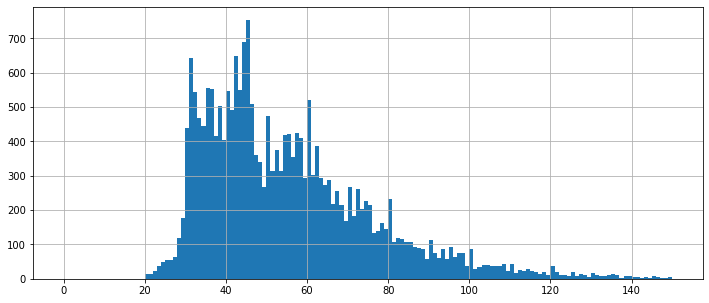

In [90]:
#let's build a histogram for total housing area

data['total_area'].hist(bins = 150, range=(0, 150), grid = True, figsize =(12, 5))

<AxesSubplot:>

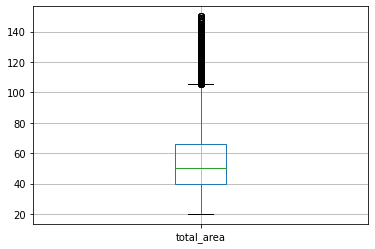

In [91]:
data.boxplot(column = ['total_area'], grid =True)

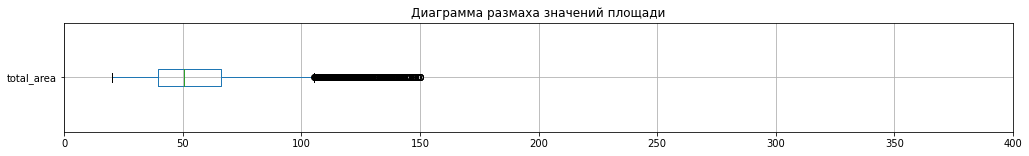

In [92]:
# check
# example of a horizontal boxplot

fig, ax = plt.subplots(figsize = (17,2))
ax = data[['total_area']].boxplot(vert = False, ax =ax)
ax.set_title('Boxplot of area values')
ax.set_xlim(0, 400);

In [93]:
data['total_area'].describe()

count    22165.000000
mean        55.170652
std         20.952466
min         20.000000
25%         39.700000
50%         50.400000
75%         66.000000
max        150.000000
Name: total_area, dtype: float64

The chart shows that most listings are for housing with a total area from 30 sq m to 80 sq m.
There's a peak value around 45 sq m.

#### Let's study the living area parameter

<AxesSubplot:>

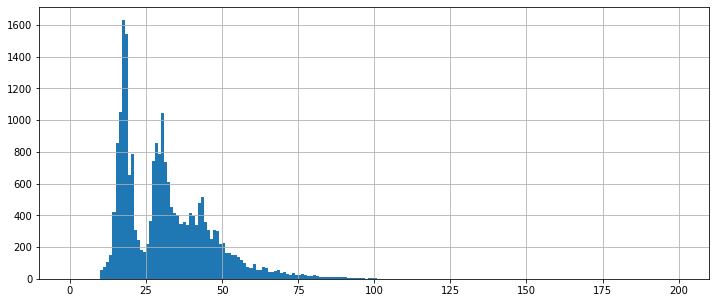

In [94]:
#let's build a histogram for living area

data['living_area'].hist(bins = 200, range=(0, 200), grid = True, figsize=(12,5))

<AxesSubplot:>

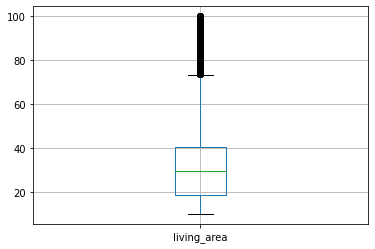

In [95]:
data.boxplot(column = ['living_area'], grid =True)

In [96]:
data['living_area'].describe()

count    22165.000000
mean        31.639596
std         14.577297
min         10.000000
25%         18.500000
50%         29.800000
75%         40.500000
max        100.000000
Name: living_area, dtype: float64

The chart shows that most housing has a living area from 15 sq m to 50.
There are two peak values at 15 and 40 sq m.

#### Let's study the kitchen area parameter

<AxesSubplot:>

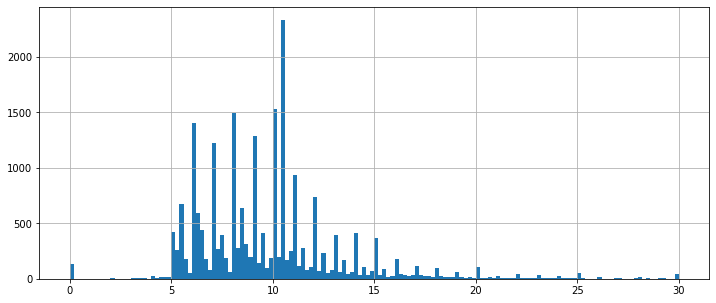

In [97]:
#let's build a histogram for the kitchen area parameter

data['kitchen_area'].hist(bins = 150, range=(0, 30), grid = True, figsize=(12, 5))

<AxesSubplot:>

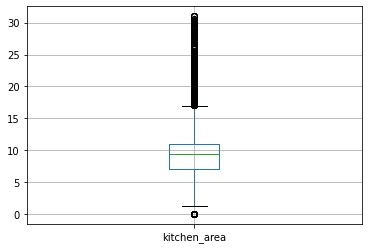

In [98]:
data.boxplot(column = ['kitchen_area'], grid =True)

In [99]:
data['kitchen_area'].describe()

count    22165.000000
mean         9.795240
std          3.763656
min          0.000000
25%          7.000000
50%          9.400000
75%         11.000000
max         31.000000
Name: kitchen_area, dtype: float64

The chart shows that the kitchen area mostly ranges from 5 to 15 sq m. A large number of listings have an 11 sq m kitchen.

#### Let's study the housing price parameter

array([[<AxesSubplot:title={'center':'last_price'}>]], dtype=object)

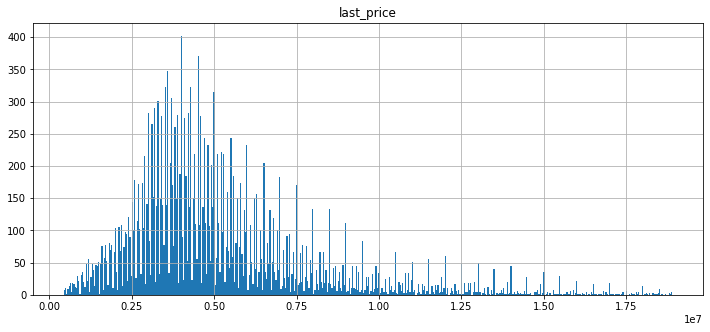

In [100]:
#let's build a histogram for housing price

data.hist('last_price', bins = 500, grid = True, figsize = (12,5))

<AxesSubplot:>

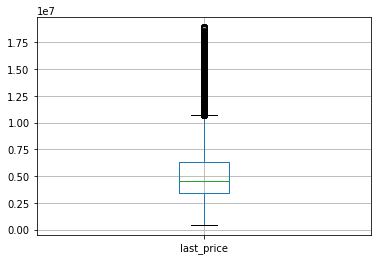

In [101]:
data.boxplot(column = ['last_price'], grid =True)

In [102]:
data['last_price'].describe()

count    2.216500e+04
mean     5.236574e+06
std      2.910127e+06
min      4.300000e+05
25%      3.385000e+06
50%      4.500000e+06
75%      6.300000e+06
max      1.890000e+07
Name: last_price, dtype: float64

 The housing-price histogram doesn't show important data to observe

#### Let's study the number-of-rooms parameter

<AxesSubplot:>

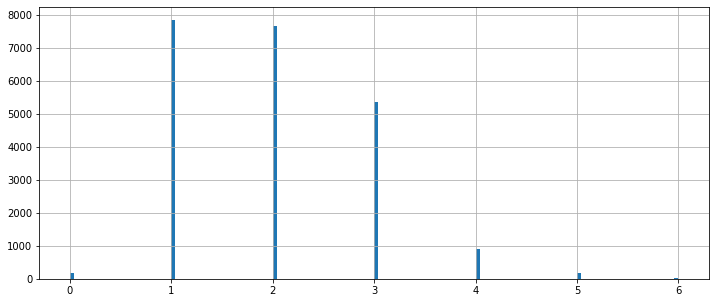

In [103]:
#let's build a histogram for the number of rooms

data['rooms'].hist(bins = 150, range=(0, 6), grid = True, figsize=(12, 5))

In [104]:
data['rooms'].describe()

count    22165.000000
mean         1.978480
std          0.933658
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

The histogram shows that most listings are for housing with 1, 2, or 3 rooms.

#### Let's study the ceiling-height data

<AxesSubplot:>

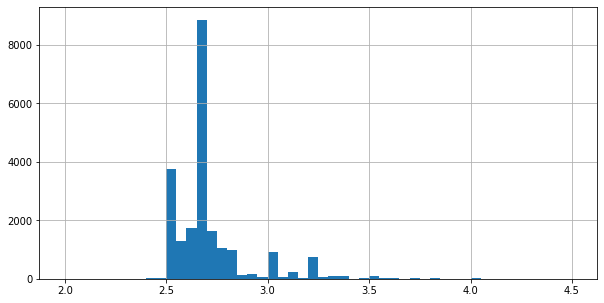

In [105]:
#let's build a histogram for ceiling height

data['ceiling_height'].hist(bins = 50, range=(2, 4.5), grid = True, figsize=(10, 5))

In [106]:
data['ceiling_height'].describe()

count    22165.000000
mean         2.709852
std          0.197735
min          2.200000
25%          2.600000
50%          2.697532
75%          2.700000
max          4.000000
Name: ceiling_height, dtype: float64

The histogram shows that ceiling height mostly ranges from 2.5 m to 2.7 m.
There's a peak value around 2.7 m.

#### Let's study the floor-category data

<AxesSubplot:>

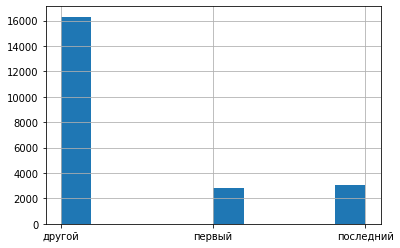

In [107]:
#let's build a histogram for floor category

data['category_floor'].hist()

In [108]:
data.groupby('category_floor')['rooms'].count()

category_floor
другой       16303
первый        2796
последний     3066
Name: rooms, dtype: int64

The histogram shows that most listings are for housing in the "other" floor category. Housing on the first and last floors has almost the same number of listings.

#### Let's study the number-of-floors parameter

<AxesSubplot:>

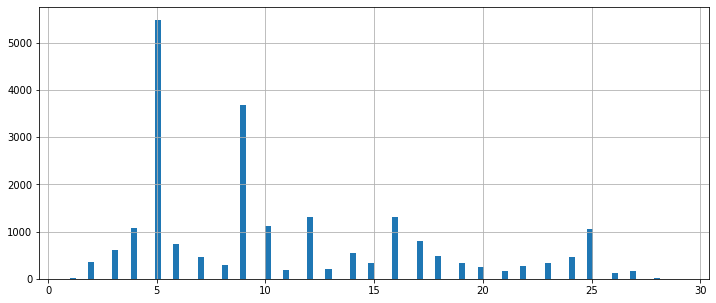

In [109]:
#let's build a histogram for the number of floors

data['floors_total'].hist(bins= 100, figsize=(12, 5))

The histogram shows that most housing is in 5-story and 9-story buildings.  

#### Let's study how far the housing is from the center

<AxesSubplot:>

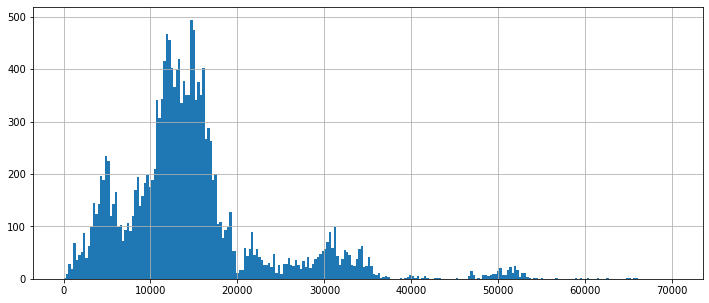

In [110]:
#let's build a histogram for the distance from housing to the city center

data['cityCenters_nearest'].hist(bins=250, range=(0, 70000), grid=True, figsize =(12, 5))

<AxesSubplot:>

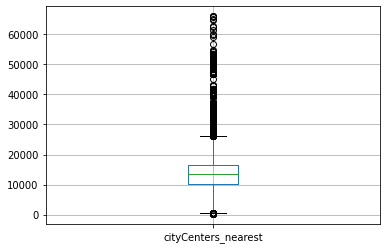

In [111]:
data.boxplot(column = ['cityCenters_nearest'], grid =True)

The histogram shows that housing is mostly located from 3000 m to 19000 m from the city center.
There are peak values around 11000-15000 m

#### Let's study the proximity-to-airport parameter

<AxesSubplot:>

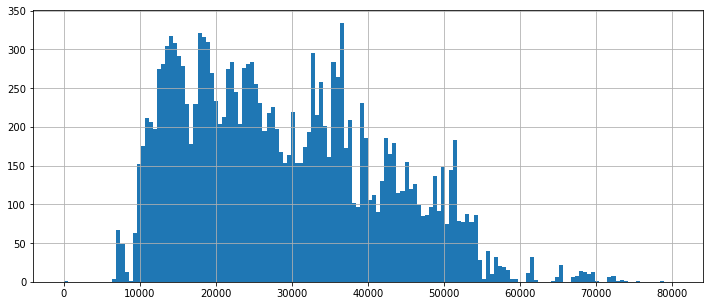

In [112]:
#let's build a histogram for the distance to the airport

data['airports_nearest'].hist(bins=150, range=(0, 80000), grid=True, figsize =(12, 5))

The histogram lets us conclude that housing is mostly located at a distance in the range
from 11000 m to 55000 m from the nearest airport.

#### Let's study the proximity-to-park parameter

<AxesSubplot:>

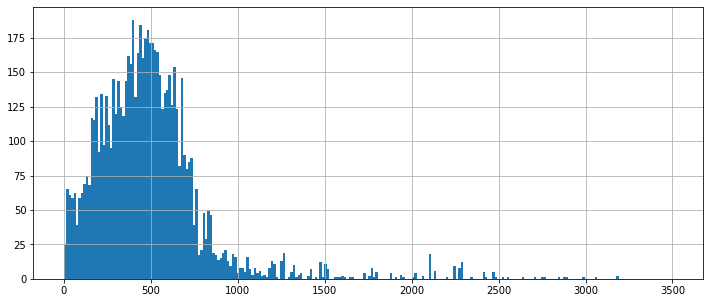

In [113]:
#let's build a histogram for the proximity of housing to a park

data['parks_nearest'].hist(bins=250, range=(0, 3500), grid=True, figsize=(12, 5))

In [114]:
data['parks_nearest'].describe()

count    7111.000000
mean      491.507664
std       334.138992
min         1.000000
25%       289.000000
50%       458.000000
75%       615.500000
max      3190.000000
Name: parks_nearest, dtype: float64

Housing is mostly close to a park, at a distance from 0 m to 700 m.
On average, park proximity is about 450 m.

#### Let's study the listing publication day

<AxesSubplot:>

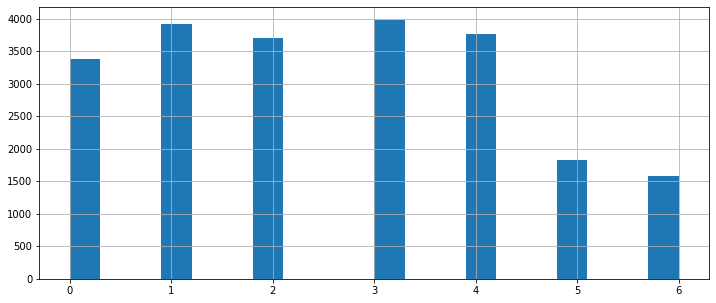

In [115]:
#let's build a histogram for the day the listing was published

data['day'].hist(bins=20, range=(0, 6), grid=True, figsize =(12, 5))

Most listings were published from Monday to Friday.

#### Let's study the listing publication month parameter

<AxesSubplot:>

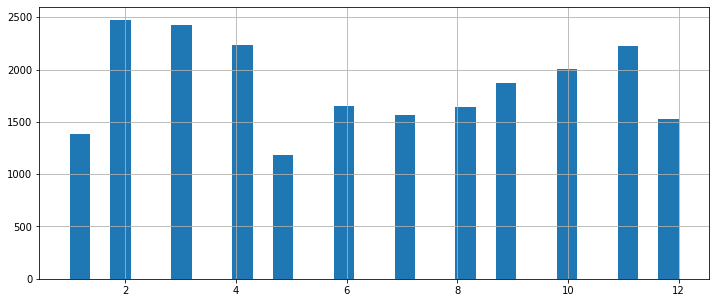

In [116]:
#let's build a histogram for the month the listing was published

data['month'].hist(bins=30, range=(1, 12), grid=True, figsize = (12, 5))

The histogram shows that most listings were published from February to April and from September to November.

#### Let's study the floor parameter of the property

<AxesSubplot:>

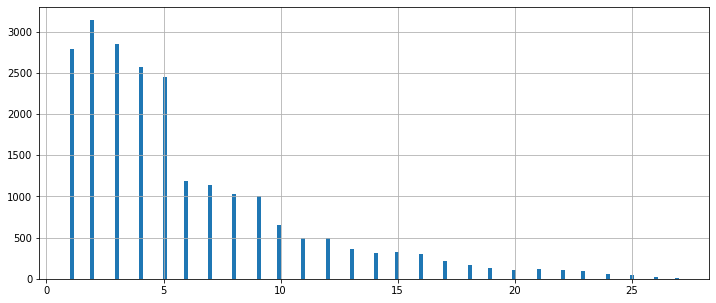

In [117]:
#let's build a histogram for the housing floor

data['floor'].hist(bins=150, grid=True, figsize = (12, 5))

The histogram shows that housing is mostly on floors 1 through 5

# example 1

#### example 3

##### example 4

#### Let's study how quickly apartments sold

<AxesSubplot:>

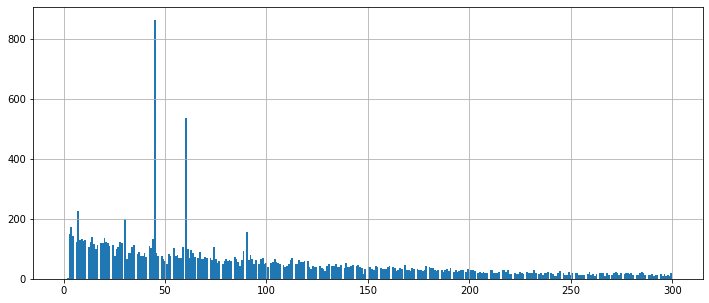

In [118]:
#let's build a histogram of the number of days the listing was published for

data['days_exposition'].hist(bins=350, range=(0, 300), grid=True, figsize =(12, 5))

In [119]:
#find the mean and median values

days_exp_mean = data['days_exposition'].mean()
days_exp_median = data['days_exposition'].median()
display(days_exp_mean)
display(days_exp_median)

171.4636645962733

92.0

The chart shows that listings stay on the site for 100 days on average, which is also confirmed by the median. There are also listings with a fairly long duration of up to 1400 days. The mean value is 171 days.

Listings over 150 days can be considered abnormally long. And under 30 fairly fast. 

#### Let's study which factors most affect the total price of the object

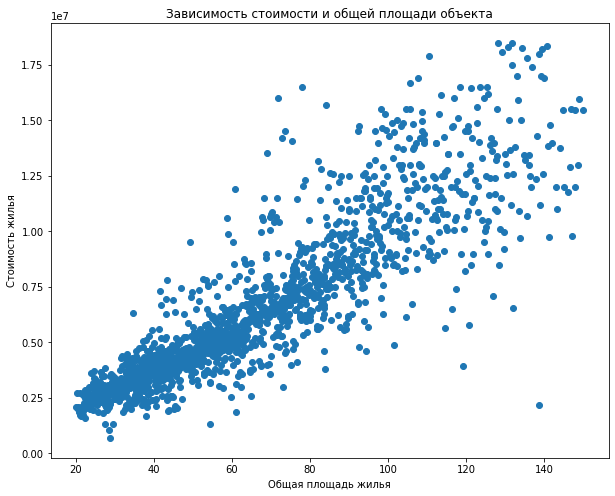

In [120]:
#let's make a pivot table for the relationship between total area and price

price_total_area = data.pivot_table(index = ['total_area'], values = 'last_price', aggfunc = 'median')
plt.figure(figsize = (10,8))

#let's build a scatter plot

plt.scatter(price_total_area.index, price_total_area['last_price'])
plt.xlabel('Total housing area')
plt.ylabel('Housing price')
plt.title('Dependence of price on total area')
plt.show()

In [121]:
data['total_area'].corr(data['last_price'])

0.7522594554349048

The chart shows that housing price is directly dependent on total area. There are also outliers on the chart.

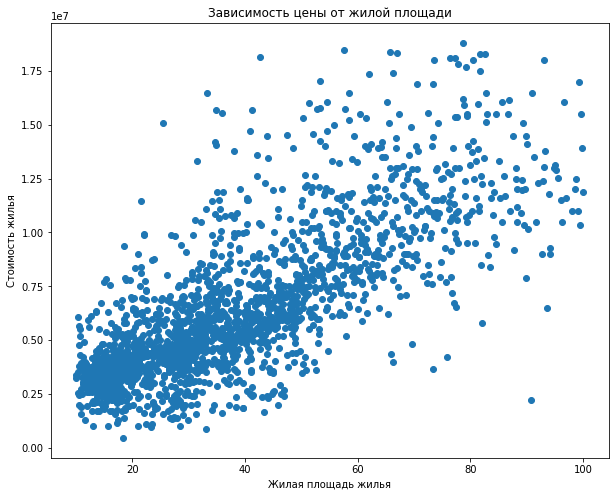

In [122]:
#let's make a pivot table for the relationship between living area and price

price_living_area = data.pivot_table(index = ['living_area'], values = 'last_price', aggfunc ='median')
plt.figure(figsize = (10,8))
#let's build the chart

plt.scatter(price_living_area.index, price_living_area['last_price'])
plt.title('Dependence of price on living area')
plt.xlabel('Living area')
plt.ylabel('Housing price')
plt.show()

In [123]:
data['living_area'].corr(data['last_price'])

0.6434039491574608

The chart shows that housing price is directly dependent on living area. There are also outliers on the chart.

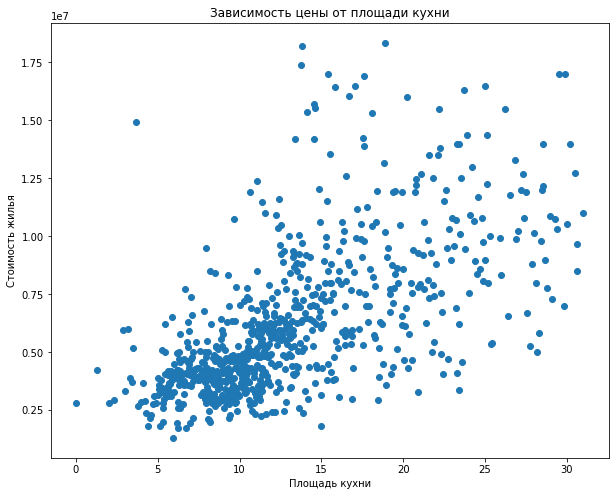

In [124]:
#let's make a pivot table for the relationship between kitchen area and price

price_kitchen_area = data.pivot_table(index = ['kitchen_area'], values = 'last_price', aggfunc = 'median')
plt.figure(figsize = (10,8))
#let's build the chart

plt.scatter(price_kitchen_area.index, price_kitchen_area['last_price'])
plt.title('Dependence of price on kitchen area')
plt.xlabel('Kitchen area')
plt.ylabel('Housing price')
plt.show()

In [125]:
#find the correlation coefficient

data['kitchen_area'].corr(data['last_price'])

0.5200171274979708

Housing price depends on kitchen area. 

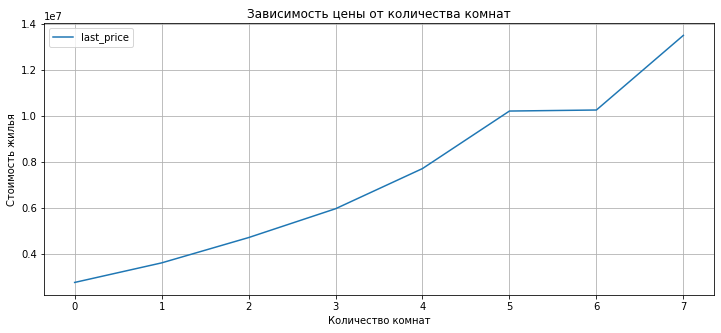

In [126]:
#let's make a pivot table for the relationship between number of rooms and price

price_rooms = data.pivot_table(index = ['rooms'], values = 'last_price', aggfunc='median' )

#let's build the chart

price_rooms.plot(grid =True, figsize =(12, 5), title = 'Dependence of price on number of rooms')
plt.xlabel('Number of rooms')
plt.ylabel('Housing price')
plt.show()

Housing price depends on the number of rooms

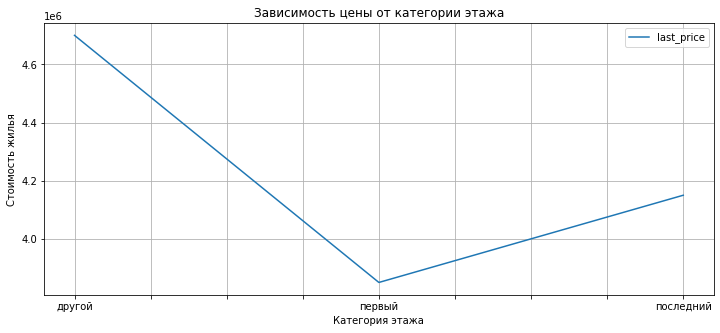

In [127]:
#let's make a pivot table for the relationship between floor category and price

price_floor = data.pivot_table(index = ['category_floor'], values = 'last_price', aggfunc='median')

#let's build the chart

price_floor.plot(grid =True, figsize =(12, 5), title = 'Dependence of price on floor category')
plt.xlabel('Floor category')
plt.ylabel('Housing price')
plt.show()

Housing price on the first floor is significantly lower compared to other floors and the last floor; the last floor is also valued lower than the others.

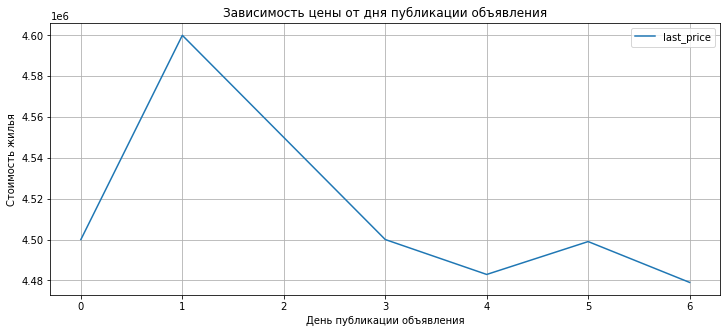

In [128]:
#let's make a pivot table for the relationship between listing publication day and price

price_day = data.pivot_table(index = ['day'], values = 'last_price', aggfunc='median')

#let's build the chart

price_day.plot(grid =True, figsize =(12, 5), title = 'Dependence of price on listing publication day')
plt.xlabel('Listing publication day')
plt.ylabel('Housing price')
plt.show()

Housing listed for sale from Monday to Wednesday has the highest price, unlike housing published on Friday, Saturday, and Sunday

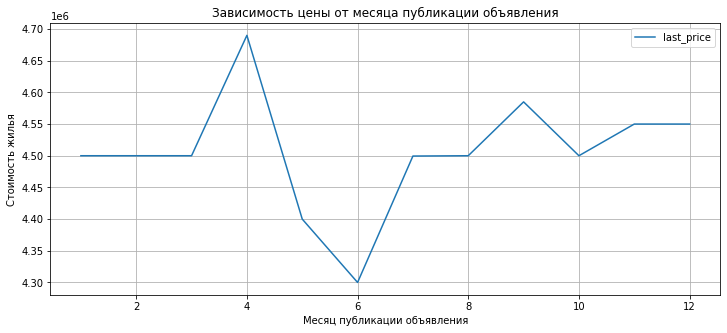

In [129]:
#let's make a pivot table for the relationship between listing publication month and price

price_month = data.pivot_table(index = ['month'], values = 'last_price', aggfunc='median')

#let's build the chart

price_month.plot(grid =True, figsize =(12, 5), title = 'Dependence of price on listing publication month')
plt.xlabel('Listing publication month')
plt.ylabel('Housing price')
plt.show()

Listings published from March to April and from November to December have a higher housing price compared to the rest.
And the lowest housing price is for listings published in June.

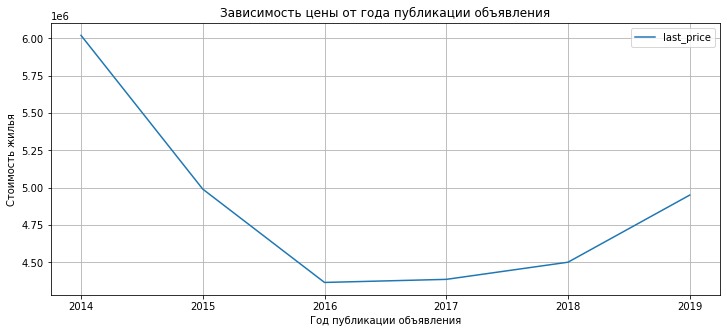

In [130]:
#let's make a pivot table for the relationship between listing publication year and price

price_year = data.pivot_table(index = ['year'], values = 'last_price', aggfunc='median')

price_year.plot(grid =True, figsize =(12, 5), title = 'Dependence of price on listing publication year')
plt.xlabel('Listing publication year')
plt.ylabel('Housing price')
plt.show()

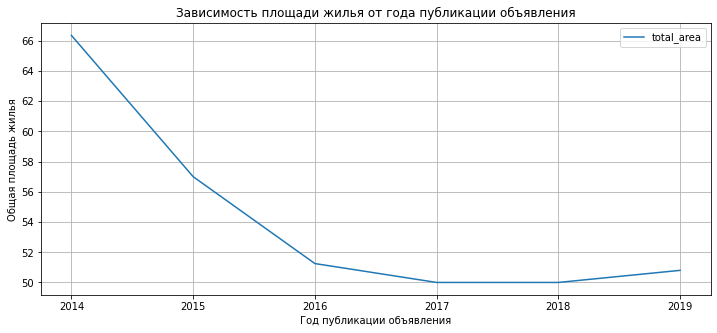

In [131]:
#let's make a pivot table for the relationship between listing publication year and total area

total_area_year = data.pivot_table(index = ['year'], values = 'total_area', aggfunc='median')

total_area_year.plot(grid =True, figsize =(12, 5),
                     title = 'Dependence of housing area on listing publication year')
plt.xlabel('Listing publication year')
plt.ylabel('Total housing area')
plt.show()

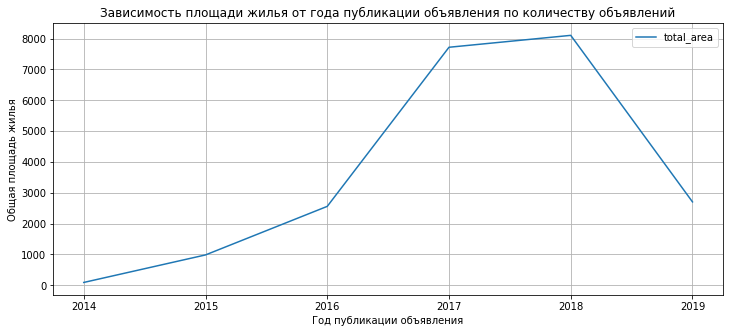

In [132]:
total_area_year = data.pivot_table(index = ['year'],
                                   values = 'total_area' , aggfunc='count')

total_area_year.plot(grid =True, figsize =(12, 5),
                     title = 'Dependence of housing area on listing publication year, by number of listings')
plt.xlabel('Listing publication year')
plt.ylabel('Total housing area')
plt.show()

The dependence of housing price on the year of publication is affected by many factors, such as the number of listings, the property's location (price directly varies with the housing's location), seasonal price fluctuations, and the share of expensive apartments with more attractive parameters relative to others. A full analysis needs to take all factors into account.

#### check

#### Let's calculate the average price per square meter in the 10 localities with the largest number of listings

In [133]:
#let's group the data by locality name and price per 1 sq m, and determine the number of listings

data1 = data.groupby('locality_name')['price_per_sqm'].agg(['count', 'mean'])

#let's sort the data by number of listings and display the first 10 localities with the largest number of listings
#and their average price per 1 sq m

data2 = data1.sort_values(by='count', ascending= False)

display(data2.head(10))

,count,mean
locality_name,,
Санкт-Петербург,14377,108169.334897
Мурино,544,85477.821530
Шушары,436,78606.071718
Всеволожск,392,67286.220972
Пушкин,348,101612.060215
Колпино,335,75315.339275
Парголово,326,90332.263023
Гатчина,304,68739.501688
Кудрово,297,92510.406482


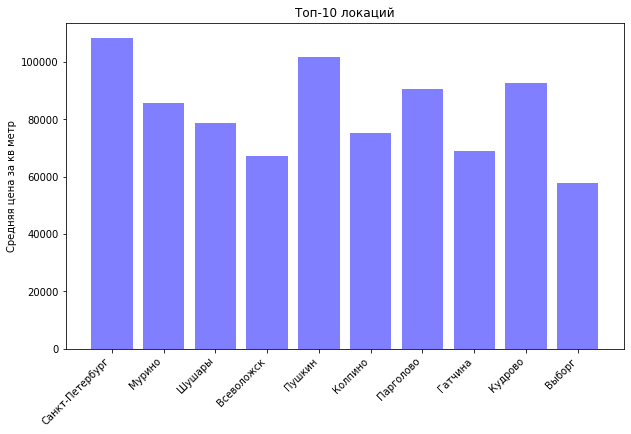

In [134]:
data_subset = data2.iloc[:10,:]['mean']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(data_subset.index, data_subset.values, color='b', alpha=0.5)
ax.set_ylabel('Average price per sq m')

ax.set_xticks(range(len(data_subset)))
ax.set_xticklabels(data_subset.index, rotation=45, ha='right')

plt.title('Top-10 locations')
plt.show()

In [135]:
#let's sort the data by price per 1 sq m in descending order

data1.sort_values(by='mean', ascending= False)

,count,mean
locality_name,,
Зеленогорск,22,108440.899937
Санкт-Петербург,14377,108169.334897
Пушкин,348,101612.060215
Сестрорецк,177,101574.742363
Лисий Нос,3,100660.814239
...,...,...
Совхозный,2,12629.129129
Выскатка,2,12335.480902
Вахнова Кара,1,11688.311688


Zelenogorsk has the highest price per 1 sq m, and Staropolye has the lowest price per 1 sq m.

#### Let's study how the price of objects depends on the distance to the city center in St. Petersburg

In [136]:
#let's take a slice of the table for all objects in St. Petersburg

spb = data.query('locality_name == "Санкт-Петербург"')

#let's make a pivot table from the slice with different distances from the center and price per km

spb_pivot = spb.pivot_table(index = 'city_center_km', values = 'last_price', aggfunc = 'mean')
display(spb_pivot)


,last_price
city_center_km,
0.0,8.798000e+06
1.0,9.900827e+06
2.0,9.176864e+06
3.0,8.457695e+06
4.0,8.929697e+06
5.0,8.929182e+06
6.0,8.218862e+06
7.0,7.587405e+06
8.0,7.533155e+06


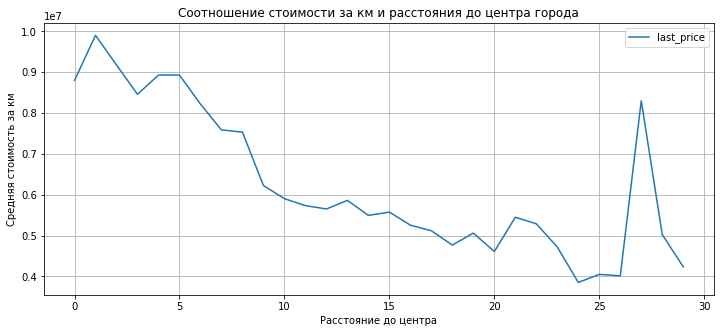

In [137]:
#let's build a chart of the price-per-km ratio and distance to the city center of St. Petersburg

spb_pivot.plot(grid =True, figsize =(12, 5), title = 'Ratio of price per km and distance to city center')
plt.xlabel('Distance to center')
plt.ylabel('Average price per km')
plt.show()

The chart shows that the closer the housing is to the city center, the more expensive it is.

In [138]:
#let's investigate the price drop at 27 km

filtered_data = data.loc[(data['locality_name'] == 'Санкт-Петербург') & (data['city_center_km'] == 27.0)]

display(filtered_data)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month,year,category_floor,city_center_km
748,13,14350000.0,74.0,2017-11-28,2,3.130000,5,30.0,3,True,...,0.0,NaN,128.0,19.0,193918.918919,1,11,2017,другой,27.0
5961,6,2250000.0,32.0,2018-02-27,1,2.697532,2,16.5,2,True,...,0.0,NaN,178.0,8.5,70312.500000,1,2,2018,последний,27.0


The property is on the second floor of a two-story building; the low price is most likely due to the type of housing

In [139]:
#let's investigate the price drop at 3 km

three_km_data = data.loc[(data['locality_name'] == 'Санкт-Петербург') &
                         (data['city_center_km'] == 3.0)]
display(three_km_data)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month,year,category_floor,city_center_km
99,32,9600000.0,90.0,2017-09-26,4,3.202702,5,67.0,2,True,...,0.0,NaN,104.0,15.0,106666.666667,1,9,2017,другой,3.0
138,8,4800000.0,40.0,2017-11-18,2,3.202702,3,29.0,2,True,...,2.0,729.0,80.0,5.0,120000.000000,5,11,2017,другой,3.0
179,5,14800000.0,108.7,2019-04-11,3,4.000000,5,72.4,5,True,...,0.0,NaN,NaN,28.3,136154.553818,3,4,2019,последний,3.0
181,2,7900000.0,71.8,2017-08-23,3,3.000000,5,38.7,1,True,...,1.0,585.0,NaN,21.1,110027.855153,2,8,2017,первый,3.0
201,5,10880000.0,123.1,2015-11-12,6,3.200000,5,89.0,2,True,...,0.0,NaN,992.0,23.1,88383.428107,3,11,2015,другой,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23176,2,6800000.0,69.2,2017-11-14,3,2.900000,5,39.9,4,True,...,1.0,666.0,447.0,20.2,98265.895954,1,11,2017,другой,3.0
23178,7,5950000.0,60.0,2018-02-01,3,2.800000,5,42.0,1,True,...,0.0,NaN,85.0,10.0,99166.666667,3,2,2018,первый,3.0
23387,7,5600000.0,50.0,2017-08-21,1,3.202702,5,27.0,1,True,...,3.0,56.0,45.0,13.0,112000.000000,0,8,2017,первый,3.0
23430,18,5260000.0,38.0,2018-11-06,1,3.300000,5,16.0,1,True,...,1.0,466.0,12.0,10.0,138421.052632,1,11,2018,первый,3.0


In [140]:
three_km_data.groupby('category_floor')['total_area'].count()

category_floor
другой       162
первый        48
последний     65
Name: total_area, dtype: int64

The price drop at 3 km is explained by the ratio of listings by floor category — from the calculations we know that housing on
the first and last floors is cheaper than on other floors. 44.81% of first and last floors out of the total number of listings at
3 km

In [141]:
#let's investigate the price drop at 5 km

five_km_data = data.loc[(data['locality_name'] == 'Санкт-Петербург') &
                         (data['city_center_km'] == 5.0)]
display(five_km_data)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,non_liv,price_per_sqm,day,month,year,category_floor,city_center_km
141,8,6500000.0,32.6,2019-02-27,1,2.697532,5,18.500000,5,True,...,0.0,NaN,NaN,8.6,199386.503067,2,2,2019,последний,5.0
159,14,7050000.0,66.0,2017-09-04,3,3.000000,4,37.800000,4,False,...,1.0,1013.0,98.0,17.2,106818.181818,0,9,2017,последний,5.0
219,12,7700000.0,58.7,2017-12-12,1,3.202702,7,17.000000,3,True,...,0.0,NaN,136.0,26.0,131175.468484,1,12,2017,другой,5.0
318,12,9990000.0,67.0,2017-07-10,1,2.840000,9,37.000000,7,True,...,1.0,713.0,50.0,13.0,149104.477612,0,7,2017,другой,5.0
320,2,12734000.0,97.0,2016-01-30,3,2.697532,10,51.200000,7,True,...,1.0,874.0,195.0,27.4,131278.350515,5,1,2016,другой,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23523,6,4599000.0,45.0,2015-06-23,2,3.202702,6,24.000000,3,True,...,0.0,NaN,800.0,13.0,102200.000000,1,6,2015,другой,5.0
23536,8,6080000.0,70.0,2018-10-12,3,2.697532,4,44.400000,4,True,...,0.0,NaN,69.0,16.6,86857.142857,4,10,2018,последний,5.0
23559,20,13800000.0,108.6,2016-09-12,3,3.202702,19,70.600000,7,True,...,1.0,503.0,354.0,27.7,127071.823204,0,9,2016,другой,5.0
23588,7,8100000.0,69.0,2015-10-14,2,2.697532,10,41.638857,8,True,...,1.0,874.0,823.0,NaN,117391.304348,2,10,2015,другой,5.0


In [142]:
five_km_data.groupby('category_floor')['total_area'].count()

category_floor
другой       536
первый        72
последний    104
Name: total_area, dtype: int64

From the calculations we can conclude that 27.54% of the total number of listings at 5 km are on the first and last floors. That's why we can observe this dip in price at 3 km.

### Overall conclusion

**When studying the data from the Yandex Real Estate service, some features were found, as well as the dependence of various parameters on the objects' price** 

**Course of the work:** Missing values were found in the data, and we worked on them. Part of the missing values was removed where this could be
done without seriously distorting the data. Part of the missing values was replaced with the mean value. We also changed the data types in the columns
where this was logically necessary.

We studied each real estate object's parameters individually, and found that most real estate objects have an area from
30 to 80 sq m, a living area from 15 to 50 sq m and an average kitchen area from 5 to 15 sq m, and have 1 to 3 rooms.
The average ceiling height is also 2.5 and 2.7 m. For the most part these real estate objects are located in 5-story and 9-story buildings. It turned out that most housing is on floors in the "other" category, and housing on the first and last floors has roughly the same number of listings.
On average, real estate objects are located 3000 m to 19000 m from the city center and 11000 m to 55000 m from the nearest airport. Proximity to a park on average ranges from 0 m to 700 m.
We also found that most listings were published from Monday to Friday, and the most active months for publishing listings are from February to April, as well as from September to November. On average, listings stay on the site for 100 days. There are also listings with a fairly long duration of up to 1400 days. Over 150 days can be considered fairly long listings. And under 30, fairly fast.

**We studied the dependence of housing price on various parameters:**

- We found that total housing area, living area, and kitchen area directly affect housing price. The larger the area, the more expensive the object.

- Housing price also increases directly with the number of rooms.

- Housing price on the first floor is significantly lower compared to other floors and the last floor; the last floor is also valued lower than the others.

- Housing listed for sale from Monday to Thursday has the highest price, unlike housing published on Friday, Saturday, and Sunday

- Listings published from March to April and from November to December have a higher housing price compared to the rest. And the lowest housing price is for listings published in June.

- The dependence of housing price on the year of publication is affected by many factors, such as the number of listings, the property's location (price directly varies with the housing's location), seasonal price fluctuations, and the share of expensive apartments with more attractive parameters relative to others. A full analysis needs to take all factors into account.

We also found that Zelenogorsk has the highest price per 1 sq m, and Staropolye has the lowest price per 1 sq m.
And housing prices in St. Petersburg increase with proximity to the city center.
A drop was found at 27 km. This is housing located on the second floor of a two-story building; the low price is most likely due to the type of housing.

The price drop at 3 km and the rise at 5 km are explained by the ratio of listings by floor category — as we found, housing on the first and last floors is cheaper than on other floors.

Recommendations:
The table had numerous gaps in the map data. This should be kept in mind to avoid data distortions going forward. It's also worth investigating the reason behind the fast-selling listings on the site.